# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [24]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [25]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [26]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [27]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [28]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [29]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [31]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

In [32]:
dados_class = pd.read_csv("aneel_classificacao_orange.csv")
print("Linhas:", len(dados_class))
print(dados_class.dtypes)
print(dados_class.isna().sum())
print(dados_class["fonte"].value_counts())
dados_class.describe()

Linhas: 3876
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000


In [33]:
X = dados_class[["potencia_kw", "latitude", "longitude"]]
y = dados_class["fonte"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=17
)
print(X_train.shape, X_test.shape)

(3100, 3) (776, 3)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_esc = scaler.transform(X_train)
X_test_esc = scaler.transform(X_test)

modelos_class = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=17),
}

previsoes = {}
for nome, modelo in modelos_class.items():
    if nome == "Random Forest":
        modelo.fit(X_train, y_train)
        previsoes[nome] = modelo.predict(X_test)
    else:
        modelo.fit(X_train_esc, y_train)
        previsoes[nome] = modelo.predict(X_test_esc)
print("Modelos treinados:", list(previsoes.keys()))

Modelos treinados: ['KNN', 'Regressão Logística', 'Random Forest']


In [35]:
resultados_class = []
for nome, y_pred in previsoes.items():
    resultados_class.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
    })
pd.DataFrame(resultados_class)

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,KNN,0.962629,0.962583,0.961036,0.961706
1,Regressão Logística,0.817010,0.823457,0.811974,0.810984
2,Random Forest,0.978093,0.978253,0.976652,0.977347


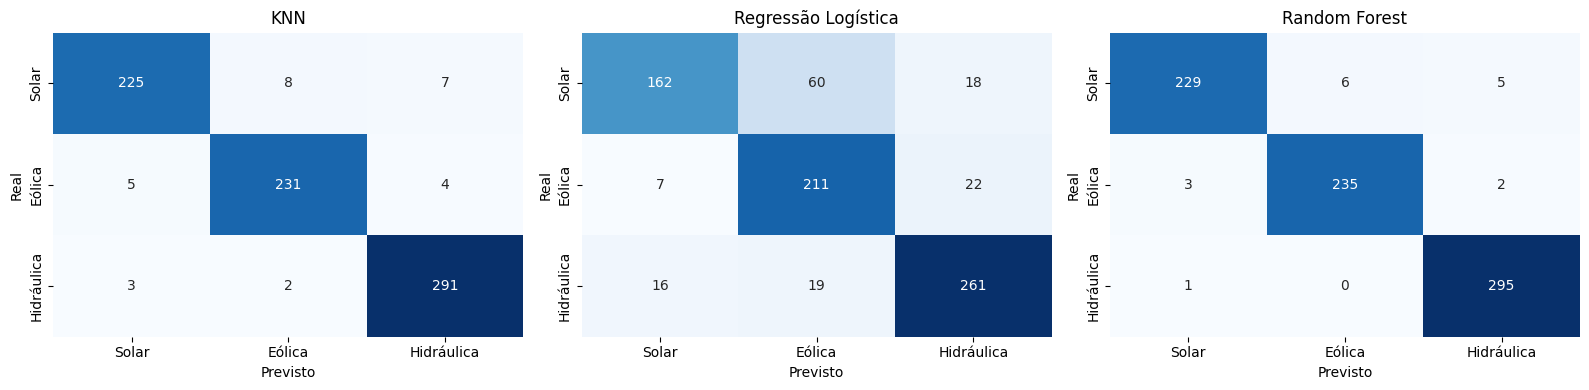

In [36]:
import seaborn as sns

classes = y.unique()
fig, eixos = plt.subplots(1, 3, figsize=(16, 4))
for eixo, (nome, y_pred) in zip(eixos, previsoes.items()):
    matriz = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=classes, yticklabels=classes, ax=eixo)
    eixo.set_xlabel("Previsto")
    eixo.set_ylabel("Real")
    eixo.set_title(nome)
plt.tight_layout()
plt.show()

### Interpretação

Os três classificadores foram avaliados na mesma divisão estratificada (80%/20%, random_state=17), com médias macro para Precision/Recall/F1:

| Modelo | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|
| KNN | 0.9626 | 0.9626 | 0.9610 | 0.9617 |
| Regressão Logística | 0.8170 | 0.8235 | 0.8120 | 0.8110 |
| Random Forest | 0.9781 | 0.9783 | 0.9767 | 0.9773 |

**Melhor modelo:** Random Forest, com F1 macro de 0,977, levemente à frente do KNN (0,962) e bem acima da Regressão Logística (0,811) — esperado, já que a fronteira entre as classes não é linear nas três entradas usadas.

**Classes mais confundidas:** olhando as matrizes de confusão, o par mais confundido em todos os modelos é Solar e Eólica. Isso fica mais claro na Regressão Logística (60 usinas Solares previstas como Eólica, e ainda 18 como Hidráulica) e persiste, em escala menor, no KNN (8 e 7) e no Random Forest (6 e 5). Já a classe Hidráulica é a mais bem separada nos três modelos (291/296 no KNN e 295/296 no Random Forest), provavelmente porque usinas hidrelétricas tendem a ter potência outorgada e localização mais distintas das demais fontes.

**Limitação do modelo:** potência outorgada e coordenadas aproximadas não capturam a tecnologia de geração em si — no Nordeste do Brasil, por exemplo, é comum parques solares e eólicos de porte semelhante estarem instalados em regiões próximas, o que explica por que justamente Solar e Eólica (e não Hidráulica) são as classes mais confundidas: o modelo não tem como ver a diferença física entre painéis e turbinas a partir só de potência/latitude/longitude. Para uma aplicação real, seria necessário incluir alguma variável que diferencie a tecnologia (ex.: perfil de geração ao longo do dia).

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [37]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [38]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [39]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [40]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


In [41]:
dados_reg = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])
print("Linhas:", len(dados_reg))
print(dados_reg.isna().sum())
dados_reg.describe()

Linhas: 1001
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


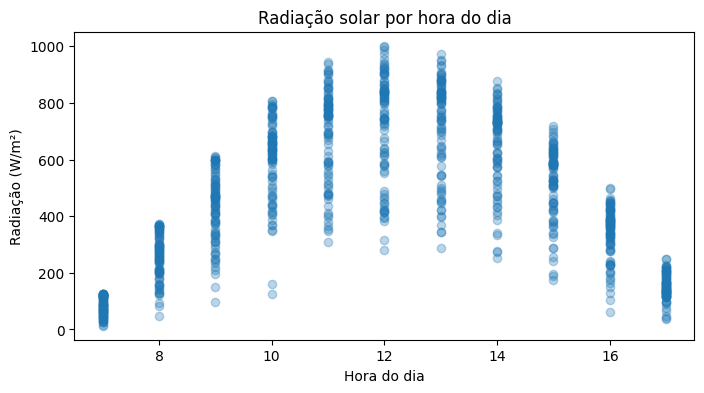

In [42]:
plt.figure(figsize=(8,4))
plt.scatter(dados_reg["hora"], dados_reg["radiacao_w_m2"], alpha=0.3)
plt.xlabel("Hora do dia")
plt.ylabel("Radiação (W/m²)")
plt.title("Radiação solar por hora do dia")
plt.show()

In [43]:
colunas_entrada = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X = dados_reg[colunas_entrada]
y = dados_reg["radiacao_w_m2"]

corte = int(len(dados_reg) * 0.8)
X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]
print(X_train.shape, X_test.shape)

(800, 5) (201, 5)


In [44]:
modelos_reg = {
    "Regressão Linear": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=17),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=17),
}

previsoes_reg = {}
for nome, modelo in modelos_reg.items():
    modelo.fit(X_train, y_train)
    previsoes_reg[nome] = modelo.predict(X_test)
print("Modelos treinados:", list(previsoes_reg.keys()))

Modelos treinados: ['Regressão Linear', 'Random Forest Regressor', 'Decision Tree Regressor']


In [45]:
resultados_reg = []
for nome, y_pred in previsoes_reg.items():
    resultados_reg.append({
        "Modelo": nome,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
    })
pd.DataFrame(resultados_reg)

,Modelo,MAE,MSE,R²
0,Regressão Linear,145.204885,30034.201092,0.359845
1,Random Forest Regressor,66.096269,7211.018315,0.846303
2,Decision Tree Regressor,86.293532,14262.671642,0.696003


Melhor modelo (maior R²): Random Forest Regressor


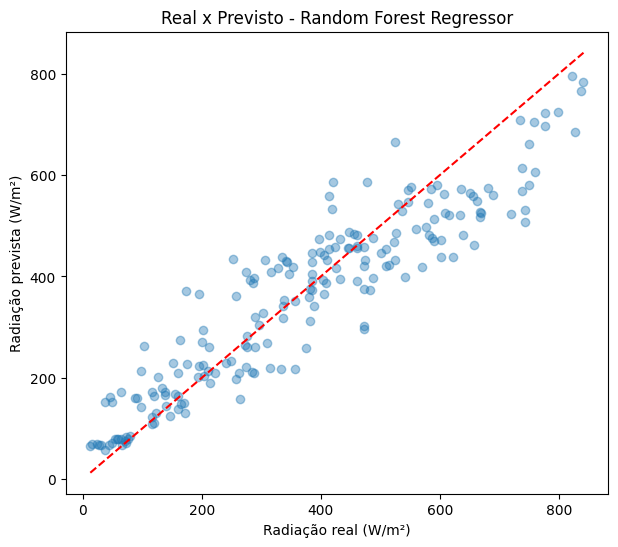

In [46]:
tabela_reg = pd.DataFrame(resultados_reg).set_index("Modelo")
melhor_modelo = tabela_reg["R²"].idxmax()
print("Melhor modelo (maior R²):", melhor_modelo)

plt.figure(figsize=(7,6))
plt.scatter(y_test, previsoes_reg[melhor_modelo], alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Radiação real (W/m²)")
plt.ylabel("Radiação prevista (W/m²)")
plt.title(f"Real x Previsto - {melhor_modelo}")
plt.show()

### Interpretação

Os três regressores foram avaliados na mesma divisão temporal (80% das primeiras horas para treino, 20% finais para teste, sem embaralhar):

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | R² |
|---|---|---|---|
| Regressão Linear | 145.20 | 30034.20 | 0.3598 |
| Random Forest Regressor | 66.10 | 7211.02 | 0.8463 |
| Decision Tree Regressor | 86.29 | 14262.67 | 0.6960 |

**Melhor modelo:** Random Forest Regressor, com o menor MAE (66,10 W/m²) e o maior R² (0,846) — bem à frente da Decision Tree (R²=0,696) e, principalmente, da Regressão Linear (R²=0,360). A diferença grande entre o modelo linear e os dois baseados em árvore indica que a relação entre as entradas (sobretudo a hora) e a radiação não é linear.

**O papel da hora:** no recorte de 7h às 17h analisado, a radiação sobe da manhã até o meio-dia e cai novamente à tarde, formando uma curva em arco (não uma reta). Um modelo linear não consegue representar bem essa subida-e-descida com um único coeficiente para a hora, o que explica seu R² muito mais baixo; já Random Forest e Decision Tree conseguem capturar relações não lineares e de interação (por exemplo, hora combinada com nuvens), por isso performam melhor.

**Por que radiação não é geração elétrica:** o valor em W/m² estimado aqui é só a energia solar que chega por área, por hora. Transformar isso em geração elétrica real exigiria ainda a área e a eficiência dos painéis instalados, o ângulo/orientação de instalação, a perda de eficiência dos painéis com o aumento da temperatura do módulo, e as perdas do inversor na conversão de corrente contínua para alternada — nenhuma dessas variáveis está nos dados usados aqui.

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)